In [1]:
!pip install langchain langchain_groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 1.6 MB/s eta 0:00:00


In [8]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

In [36]:
class BlogLLM(TypedDict):
  title: str
  outline: str
  content: str
  evaluation: int

In [46]:
import os
os.environ["GROQ_API_KEY"]="write your api key"

In [26]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.7)

In [27]:
def outline_generator(state: BlogLLM)-> BlogLLM:
  # getting the title form the state
  title = state['title']

  # creating the prompt:
  prompt = f"create a proper outline for the title: {title}"

  # invoking the prompt
  outline = LLM.invoke(prompt).content

  state['outline'] = outline

  return state

In [28]:
def blog_generator(state: BlogLLM)-> BlogLLM:
  # taking the outline form state
  title = state['title']
  outline = state['outline']

  prompt = f"write a detailed blog for the title {title} having the outline {outline}"

  content = LLM.invoke(prompt).content

  state['content'] = content

  return state


In [37]:
def content_evaluator(state: BlogLLM)-> BlogLLM:

  blog = state['content']

  prompt = f"evaluate the following blog in numbers from 1 to 10: {blog}"

  evaluation = LLM.invoke(prompt).content

  state['evaluation'] = evaluation

  return state


In [39]:
# graph
graph = StateGraph(BlogLLM)

# node
graph.add_node("outline_generation", outline_generator)
graph.add_node("blog_generator", blog_generator)
graph.add_node("content_evaluator", content_evaluator)

# edges
graph.add_edge(START, "outline_generation")
graph.add_edge("outline_generation", "blog_generator")
graph.add_edge("blog_generator", "content_evaluator")
graph.add_edge("content_evaluator", END)

# complining the graph
workflow = graph.compile()

In [40]:
# executing the graph
initial_state = {"title": "Old Kingdom vs new Kingdom in ancient egypt"}
output_state = workflow.invoke(initial_state)

In [41]:
print(output_state)

{'title': 'Old Kingdom vs new Kingdom in ancient egypt', 'outline': '**Outline – “Old Kingdom vs. New Kingdom in Ancient Egypt”**  \n\n---\n\n### I. Introduction  \n1. **Hook** – A vivid image or anecdote (e.g., the towering pyramids of Giza vs. the opulent temples of Karnak).  \n2. **Brief overview** – Timeframes:  \n   - Old Kingdom\u202f≈\u202fc.\u202f2686–2181\u202fBCE (3rd–6th Dynasties)  \n   - New Kingdom\u202f≈\u202fc.\u202f1550–1070\u202fBCE (18th–20th Dynasties)  \n3. **Purpose & Scope** – Explain why comparing these two “golden ages” matters for understanding Egyptian state‑formation, culture, and legacy.  \n4. **Thesis statement** – While both periods represent peaks of political power and artistic achievement, the Old Kingdom is defined by centralized bureaucratic administration and monumental funerary architecture, whereas the New Kingdom is characterized by imperial expansion, religious transformation, and a more complex, cosmopolitan society.  \n\n---\n\n### II. Histori

In [42]:
print(output_state['outline'])

**Outline – “Old Kingdom vs. New Kingdom in Ancient Egypt”**  

---

### I. Introduction  
1. **Hook** – A vivid image or anecdote (e.g., the towering pyramids of Giza vs. the opulent temples of Karnak).  
2. **Brief overview** – Timeframes:  
   - Old Kingdom ≈ c. 2686–2181 BCE (3rd–6th Dynasties)  
   - New Kingdom ≈ c. 1550–1070 BCE (18th–20th Dynasties)  
3. **Purpose & Scope** – Explain why comparing these two “golden ages” matters for understanding Egyptian state‑formation, culture, and legacy.  
4. **Thesis statement** – While both periods represent peaks of political power and artistic achievement, the Old Kingdom is defined by centralized bureaucratic administration and monumental funerary architecture, whereas the New Kingdom is characterized by imperial expansion, religious transformation, and a more complex, cosmopolitan society.  

---

### II. Historical Context & Political Structure  

| Aspect | Old Kingdom | New Kingdom |
|--------|-------------|-------------|
| **Foun

In [43]:
print(output_state['content'])

**Old Kingdom vs. New Kingdom in Ancient Egypt**  
*Two “golden ages” that shaped the world’s most iconic civilization*  

---

## I. Introduction  

### 1. Hook – A Picture Worth a Thousand Years  

Imagine standing on the desert plateau of Giza at sunrise. The three great pyramids cast long, perfect shadows across the sand, their limestone faces glittering like frozen thunder. Now, fast‑forward a thousand years and picture yourself walking through the soaring hypostyle hall of Karnak, where towering columns are wrapped in hieroglyphic bands and the air hums with the chant of priests. Both scenes belong to Egypt, but they belong to **different ages**—the Old Kingdom and the New Kingdom—each a distinct expression of power, belief, and imagination.

### 2. Brief Overview – When the Ages Began and Ended  

| Period | Approximate Dates | Dynastic Range |
|--------|-------------------|----------------|
| **Old Kingdom** | c. 2686 – 2181 BCE | 3rd – 6th Dynasties |
| **New Kingdom** | c. 15

In [45]:
print(output_state['evaluation'])

**Overall Rating: 8 / 10**  

Below is a breakdown of the blog’s strengths and areas for improvement, scored on a 1 – 10 scale (1 = very weak, 10 = exceptional).

| Criterion | Score | Why |
|-----------|-------|-----|
| **Historical Accuracy** | **9** | Dates, dynastic ranges, and major events are spot‑on. The political, economic, and religious details are well‑sourced and reflect current scholarship (e.g., Amarna letters, Pyramid Texts, Book of the Dead). |
| **Depth & Breadth of Content** | **8** | The post covers five major dimensions (politics, economy, religion, art/architecture, military) plus social life, giving a comprehensive picture. A few sub‑topics (e.g., daily life of women, environmental factors) could be expanded, but the coverage is already robust. |
| **Organization & Structure** | **9** | Clear headings, logical progression from introduction to conclusion, and helpful tables make the piece easy to navigate. The “Founding Circumstances” and “Government Model” sections

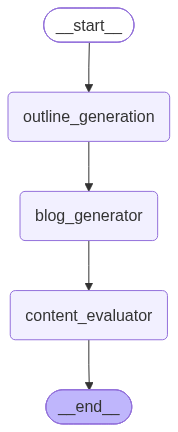

In [44]:
#lets visualize the image
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())